# Plot Interattivo - Teorie di Chambers
Confronta la **teoria a gradino** e la **teoria cos$^4$ (Bessel)** con i dati sperimentali.
Modifica i parametri nelle celle seguenti e riesegui per aggiornare i grafici.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import iv
from tqdm.notebook import tqdm
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from matplotlib import cm
import importlib, vik_lib
importlib.reload(vik_lib)
from vik_lib import fit_with_bar, plot_observable_4panel

%matplotlib inline

# Stile grafici
font1 = {'family': 'serif', 'color': 'black', 'size': 20}
font2 = {'family': 'serif', 'color': 'black', 'size': 15}

Funzioni definite.
Funzioni definite.


In [2]:
columns_names = ['B_S1', 'rho_ratio_S1', 'B_S2', 'rho_ratio_S2', 'B_Nd', 'rho_ratio_Nd']
df = pd.read_csv('Data/Ataei/41567_2022_1763_MOESM2_ESM.txt', sep=r'\s+', skiprows=2, names=columns_names)

def estrai_mr(col_B, col_rho):
    temp = df[[col_B, col_rho]].dropna()
    return temp[col_B].values.astype(float), temp[col_rho].values.astype(float) - 1.0

B_S1, MR_S1 = estrai_mr('B_S1', 'rho_ratio_S1')
B_S2, MR_S2 = estrai_mr('B_S2', 'rho_ratio_S2')
B_Nd, MR_Nd = estrai_mr('B_Nd', 'rho_ratio_Nd')

DATASETS = {
    'LSCO S1': (B_S1, MR_S1),
    'LSCO S2': (B_S2, MR_S2),
    'Nd-LSCO': (B_Nd, MR_Nd),
}
print('Dati caricati:', {k: len(v[0]) for k, v in DATASETS.items()})

Dati caricati: {'LSCO S1': 3872, 'LSCO S2': 10272, 'Nd-LSCO': 9895}


In [3]:
# =================================================================
# COSTANTI E FUNZIONI FISICHE DI BASE
# =================================================================

K_MEV = 0.116  # hbar*e/m_e: hbar*omega_c [meV] = K_MEV * B[T] / m_star[m_e]

def com_omega(B, m_star):
    """Frequenza ciclotrone hbar*omega_c [meV]  (B in T, m_star in m_e)."""
    return K_MEV * B / m_star

def com_alpha(G_an, B, m_star):
    """Parametro di anisotropia: alpha = G_an / (8 * hbar*omega_c)."""
    return G_an / (8.0 * com_omega(B, m_star))


# =================================================================
# MODELLO 1 - GRADINO (Chambers step-function)
# Parametri: Gamma1, Gamma2 [meV] | phi_star [rad] | m_star [m_e]
# =================================================================

def _sigma_complex_step(B, Gamma1, Gamma2, phi_star, m_star):
    """Ritorna O_I1 + O_I2 complesso.
       sigma_xx = Re(.)   sigma_xy = Im(.)"""
    psi_star = np.pi / 4 - phi_star
    w = com_omega(B, m_star)
    w = np.where(w == 0, 1e-12, w)
    S1 = 2 * psi_star / w
    S2 = 2 * phi_star  / w

    denom = 1 + 1j * np.exp(-(Gamma1 * S2 + Gamma2 * S1))
    Z12 = ((1 - np.exp(-(Gamma2 + 1j*w) * S1)) / denom
           * (1/(Gamma2 + 1j*w) - 1/(Gamma1 + 1j*w)))
    Z21 = ((1 - np.exp(-(Gamma1 + 1j*w) * S2)) / denom
           * (1/(Gamma1 + 1j*w) - 1/(Gamma2 + 1j*w)))
    t1  = (1 - np.exp(-(Gamma1 + 1j*w) * S2)) / 2.0
    t2  = (1 - np.exp(-(Gamma2 + 1j*w) * S1)) / 2.0

    O_I1 = (4 / (Gamma1**2 + w**2)) * (Gamma1 - 1j*w) * (phi_star + Z12 * w * t1)
    O_I2 = (4 / (Gamma2**2 + w**2)) * (Gamma2 - 1j*w) * (psi_star + Z21 * w * t2)
    # Convenzione hole-like: coniugo per avere sigma_xy > 0 (flip q -> -q, ovvero omega -> -omega).
    return np.conj(O_I1 + O_I2)

def sigma_xx_step(B, Gamma1, Gamma2, phi_star, m_star):
    return np.real(_sigma_complex_step(B, Gamma1, Gamma2, phi_star, m_star))

def sigma_xy_step(B, Gamma1, Gamma2, phi_star, m_star):
    return np.imag(_sigma_complex_step(B, Gamma1, Gamma2, phi_star, m_star))

def mr_step(B, Gamma1, Gamma2, phi_star, m_star):
    sig0 = sigma_xx_step(np.array([1e-8]), Gamma1, Gamma2, phi_star, m_star)[0]
    return sig0 / sigma_xx_step(B, Gamma1, Gamma2, phi_star, m_star) - 1.0


# =================================================================
# MODELLO 2a - COS^4/BESSEL normalizzato
# Parametri: mu (= wc*tau/B_rif) | gamma_ratio (= G_an/G_tilde)
# =================================================================

def _calc_cN(t, alpha, N, mu_max=15):
    c_N = np.zeros_like(alpha, dtype=float)
    for mu in range(-mu_max, mu_max + 1):
        sgn = (-1.0)**mu
        c_N += sgn * (iv(t - 2*mu,       alpha) * iv(mu,     alpha / 8.0)
                    * iv(t - 2*(mu - N), alpha) * iv(mu - N, alpha / 8.0))
    return c_N

def sigma_xx_bessel_norm(x, gamma_ratio, t_max=15):
    """sigma_xx adimensionale: x = mu*B."""
    x     = np.where(x < 1e-6, 1e-6, x)
    alpha = np.clip(gamma_ratio / (8.0 * x), -150.0, 150.0)
    sigma = np.zeros_like(x, dtype=float)
    for t in range(-t_max, t_max + 1):
        t_an = 4.0 * t + 1.0
        c0   = _calc_cN(t, alpha, N=0)
        c1   = _calc_cN(t, alpha, N=1)
        sigma += (-1.0)**t * (c0 - x * t_an * c1) / (1.0 + (x * t_an)**2)
    return sigma

def mr_bessel(B, mu, gamma_ratio):
    sig0 = 1.0 / np.sqrt(1.0 - gamma_ratio**2)
    return sig0 / sigma_xx_bessel_norm(mu * B, gamma_ratio) - 1.0


# =================================================================
# MODELLO 2b - COS^4/BESSEL in unita fisiche (per fit)
# Parametri: A | G_is, G_an [meV] | m_star [m_e]
#
# Ottimizzazioni:
#  - iv(mu, alpha/8) e iv(mu-N, alpha/8) sono t-indipendenti: fuori dal loop.
#  - Si precompila I_alpha[k,B] = iv(k, alpha) e I_alpha8[k,B] = iv(k, alpha/8)
#    una volta sola per tutti gli ordini interi richiesti; dentro il loop di t
#    si indicizza (sfruttando iv(-n,x)=iv(n,x)) invece di chiamare iv.
# =================================================================

# Convenzione: A (prefattore globale di sigma_xx, sigma_xy) e' FISSATO a 1.
# In MR = sigma_0/sigma_xx - 1 il fattore A si cancella, per cui puo' essere
# omesso sia dalla definizione di sigma_xx/xy sia dal set di parametri del fit.
#
# NB: per B -> 0 si ha alpha = G_an/(8*hbar*omega_c) -> infinito e iv(k, alpha)
# diverge. Il calcolo di sigma_0 in MR_Bessel aggira la singolarita' valutando
# sigma_xx a un B_ref scelto nel plateau della serie (alpha_ref ~ 10), dove
# sigma_xx ha raggiunto il suo limite di campo basso numericamente stabile.

def _sigma_Bessel_complex(B, G_is, G_an, m_star, t_max=30, s_max=2, mu_max=10):
    """Calcola sigma_xx + i*sigma_xy nel modello cos^4/Bessel (A=1 implicito).
    Re(.) = sigma_xx, Im(.) = sigma_xy.

    Deriva dalla fattorizzazione
        numer = (G_tilde - i*omega*t_an) * sum_s (-1)^s (c_{2s} - i*c_{2s+1}),
    la cui parte reale e' G_tilde*c_{2s} - omega*t_an*c_{2s+1}  (= sigma_xx),
    quella immaginaria e' -G_tilde*c_{2s+1} - omega*t_an*c_{2s}  (= sigma_xy).
    """
    B       = np.atleast_1d(B).astype(float)
    alpha   = com_alpha(G_an, B, m_star)
    omega   = com_omega(B, m_star)
    G_tilde = G_is + 3 * G_an / 8

    s_arr   = np.arange(-s_max, s_max + 1)
    sign_s  = (-1.0) ** s_arr
    N_all   = np.concatenate([2*s_arr, 2*s_arr + 1])
    mu_arr  = np.arange(-mu_max, mu_max + 1)
    sign_mu = (-1.0) ** mu_arr

    N_abs     = int(np.max(np.abs(N_all)))
    k_al_max  = t_max + 2*mu_max + 2*N_abs
    k_al8_max = mu_max + N_abs
    k_al  = np.arange(0, k_al_max + 1)
    k_al8 = np.arange(0, k_al8_max + 1)
    I_al  = iv(k_al[:,  None], alpha[None, :])
    I_al8 = iv(k_al8[:, None], alpha[None, :] / 8.0)

    iv_mu_al8  = I_al8[np.abs(mu_arr), :]
    iv_muN_al8 = I_al8[np.abs(mu_arr[:, None] - N_all[None, :]), :]

    ns   = len(s_arr)
    temp = np.zeros_like(alpha, dtype=complex)
    for t in range(-t_max, t_max + 1):
        t_an   = 4 * t + 1
        denom  = G_tilde**2 + (omega * t_an)**2
        sign_t = (-1.0) ** t

        iv_tm_al  = I_al[np.abs(t - 2*mu_arr), :]
        iv_tmN_al = I_al[np.abs(t - 2*mu_arr[:, None] + 2*N_all[None, :]), :]

        A_mu = sign_mu[:, None] * iv_tm_al * iv_mu_al8

        zeta_all = np.einsum('mb,mnb,mnb->nb',
                             A_mu, iv_tmN_al, iv_muN_al8)

        # Forma complessa: (G_tilde - i omega t_an) * sum_s (-1)^s (c_{2s} - i c_{2s+1})
        sum_s_c = np.sum(sign_s[:, None] * (zeta_all[:ns] - 1j * zeta_all[ns:]), axis=0)
        inner_c = (G_tilde - 1j * omega * t_an) * sum_s_c

        temp += sign_t * inner_c / denom

    # Convenzione hole-like: coniugo per avere sigma_xy > 0.
    return np.conj(np.pi * temp)

def sigma_xx_Bessel(B, G_is, G_an, m_star, t_max=30, s_max=2, mu_max=10):
    return np.real(_sigma_Bessel_complex(B, G_is, G_an, m_star, t_max, s_max, mu_max))

def sigma_xy_Bessel(B, G_is, G_an, m_star, t_max=30, s_max=2, mu_max=10):
    return np.imag(_sigma_Bessel_complex(B, G_is, G_an, m_star, t_max, s_max, mu_max))

def _B_ref_bessel(G_an, m_star, alpha_ref=10.0, B_min=0.5):
    """Scelta di B_ref per sigma_0: si mette nel plateau della serie Bessel,
    cioe' dove alpha(B_ref) ~ alpha_ref (~10). A B_ref minore iv(k, alpha)
    esplode numericamente; a B_ref maggiore si abbandona il plateau e sigma_xx
    gia' decresce. B_min e' una soglia di sicurezza per G_an*m_star molto piccolo."""
    return max(G_an * m_star / (8.0 * K_MEV * alpha_ref), B_min)

def MR_Bessel(B, G_is, G_an, m_star):
    """MR = sigma_0 / sigma_xx - 1.  Il prefattore A si cancella.

    sigma_0 e' approssimato da sigma_xx(B_ref) con B_ref nel plateau
    (alpha ~ 10), regime numericamente stabile. Per B < B_ref la serie di
    Bessel diverge (iv(k, alpha) overflow), ma fisicamente siamo nel plateau
    sigma_xx(B) ~ sigma_0, quindi MR(B) ~ 0: la maschera restituisce 0 in
    quel range invece di -1 (che romperebbe il Jacobiano di curve_fit)."""
    B     = np.atleast_1d(B).astype(float)
    B_ref = _B_ref_bessel(G_an, m_star)
    sig0  = sigma_xx_Bessel(np.array([B_ref]), G_is, G_an, m_star)[0]
    out   = np.zeros_like(B)
    mask  = B >= B_ref
    if mask.any():
        sig_stab = sigma_xx_Bessel(B[mask], G_is, G_an, m_star)
        out[mask] = sig0 / sig_stab - 1.0
    return out


# =================================================================
# UTILITY
# =================================================================

def clip_mr(arr, nome=''):
    """Imposta a 0 i valori negativi di MR e stampa un avviso."""
    n_neg = int(np.sum(arr < 0))
    if n_neg > 0:
        tag = f'[{nome}] ' if nome else ''
        print(f'  WARNING: {tag}{n_neg} punti con MR < 0 -> impostati a 0')
    return np.clip(arr, 0.0, None)

#================= Definizioni T-dependence
# Gamma(T) = a * T^2  con a fissato dalla condizione
#     Gamma(T_exp) = Gamma_fit   ==>   a = Gamma_fit / T_exp^2.
def G1_T(T):   return a1   * np.asarray(T, dtype=float)**2
def G2_T(T):   return a2   * np.asarray(T, dtype=float)**2 
def G_is_T(T): return a_is * np.asarray(T, dtype=float)
# Bessel - Planckian/Ong style: G_is (isotropo) ~ T, lineare in T come atteso
# dalla dissipazione Planckian kB*T/hbar. G_an (anisotropo, cold-spots) e'
# T-indipendente. Il rapporto G_an/G_is diverge a T piccolo -> picco di R_H
# a bassa T. Motivazione empirica: fit rho(T) di Ataei MOESM1 -> p ~ 1.
def G_an_T(T): return G_an_fit * np.ones_like(np.asarray(T, dtype=float))**2
PHI_MAX = np.pi / 4 - 1e-4   # asintoto di phi*(T); evita la singolarita' esatta a pi/4

def phi_star_T(T):
    """phi*(T) = PHI_MAX * tanh(T / T_scale_phi).
       T_scale_phi e' ricavato dalla condizione phi*(T_exp) = phi_star_fit,
       quindi il vincolo e' esatto. A T=0 phi* = 0 (limite anisotropo puro)."""
    return PHI_MAX * np.tanh(np.asarray(T, dtype=float) / T_scale_phi)

---
## Fit

Campione: LSCO S2  |  B in [5.00, 85.25] T  |  532 punti


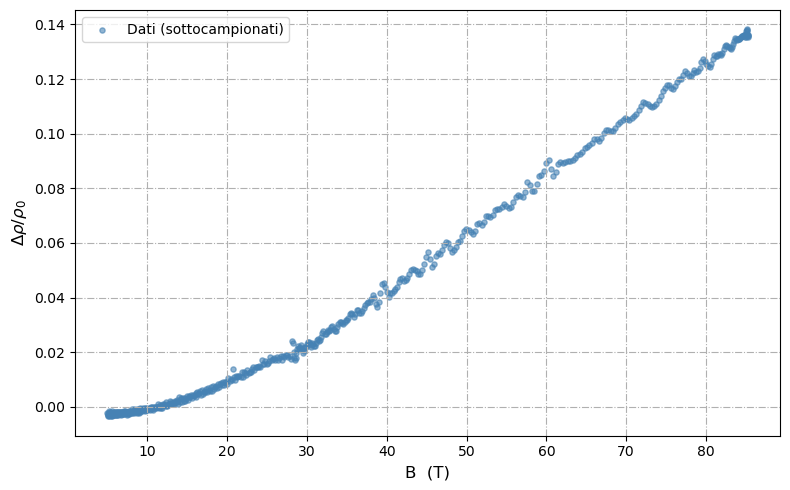

In [4]:
# -- Intervallo dati da fittare --------------------------------------
DATASET_FIT = 'LSCO S2'   # 'LSCO S1' | 'LSCO S2' | 'Nd-LSCO'

B_min_fit = 5    # Campo magnetico minimo  [T]
B_max_fit = 100.0   # Campo magnetico massimo [T]
step      = 10

# --------------------------------------------------------------------
B_exp, MR_exp = DATASETS[DATASET_FIT]

mask   = (B_exp >= B_min_fit) & (B_exp <= B_max_fit)
B_fit  = B_exp[mask][::step]
MR_fit = MR_exp[mask][::step]
B_plot = np.linspace(B_min_fit, B_max_fit, 500)

print(f'Campione: {DATASET_FIT}  |  B in [{B_fit.min():.2f}, {B_fit.max():.2f}] T  |  {len(B_fit)} punti')

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(B_fit, MR_fit, s=14, color='steelblue', alpha=0.6, label='Dati (sottocampionati)')
ax.set_xlabel('B  (T)', fontsize=12)
ax.set_ylabel(r'$\Delta\rho/\rho_0$', fontsize=12)
ax.legend()
ax.grid(linestyle='-.')
plt.tight_layout()
plt.show()

In [5]:
popt_bessel, pcov_bessel = fit_with_bar(
    MR_Bessel, B_fit, MR_fit,
    guess=[17.7, 39, 1],
    bounds=([17.699999, 38.9999999, 0.1], [17.7000001, 39.0000001, 15])
)

popt_step, pcov_step = fit_with_bar(
    mr_step, B_exp, MR_exp,
    guess=[10, 40, np.pi/8, 2],
    bounds=([0, 0, 0, 1], [100, 100, np.pi/8, 10])
)

print('\nBessel  -> G_is={:.3f}  G_an={:.3f}  m*={:.3f}'.format(*popt_bessel))
print('Gradino -> G1={:.3f}  G2={:.3f}  phi*={:.3f}rad  m*={:.3f}'.format(*popt_step))

Fitting  MR_Bessel:   0%|          | 0/1000 [00:00<?, ? eval/s]

Fitting  mr_step:   0%|          | 0/1000 [00:00<?, ? eval/s]


Bessel  -> G_is=17.700  G_an=39.000  m*=1.485
Gradino -> G1=19.552  G2=27.084  phi*=0.393rad  m*=1.216


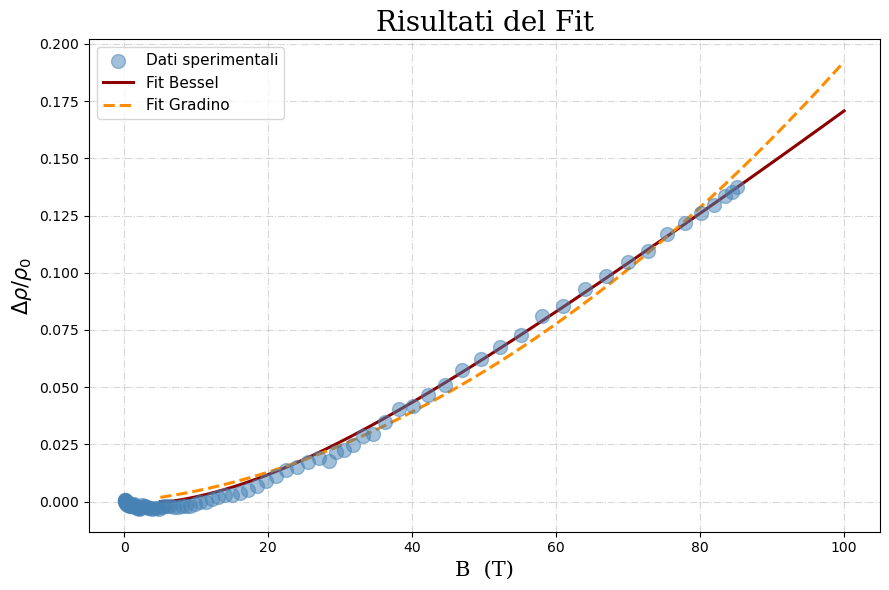

In [6]:
y_bessel = clip_mr(MR_Bessel(B_plot, *popt_bessel), 'Bessel')
y_step   = clip_mr(mr_step(B_plot,   *popt_step),    'Gradino')

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(B_exp[::100], MR_exp[::100], s=100, color='steelblue',
           alpha=0.5, label='Dati sperimentali', zorder=3)
ax.plot(B_plot, y_bessel, color='darkred',    linewidth=2.2, label='Fit Bessel')
ax.plot(B_plot, y_step,   color='darkorange', linewidth=2.2,
        linestyle='--', label='Fit Gradino')
ax.set_xlabel('B  (T)', fontdict = font2)
ax.set_ylabel(r'$\Delta\rho/\rho_0$', fontdict = font2)
ax.set_title('Risultati del Fit', fontdict = font1)
ax.legend(fontsize=11)
ax.grid(linestyle='-.', alpha=0.5)
plt.tight_layout()
plt.show()

---
## Dipendenza dalla temperatura (modello a GRADINO)
Inseriamo una dipendenza da $T$ nei parametri ottenuti dal fit:

- $\Gamma_i(T) = a_i\,T^2 + b_i$
- $\phi^*(T) = c\,T + \phi^*_0$

I coefficienti $b_1, b_2, \phi^*_0$ sono i valori del fit (interpretati come $T\to 0$).

Su questa griglia $(B, T)$ si calcolano:
- $\rho_{xx}(B, T) = 1/\sigma_{xx}$
- $R_H(B, T) = \sigma_{xx}/(B\,\sigma_{xy})$
- $\cot\theta_H(B, T) = \sigma_{xx}/\sigma_{xy}$

In [13]:
# =================================================================
# Griglie (B, T) per sigma_xx, sigma_xy, rho_xx, R_H, cot(theta_H)
# =================================================================

# Valori di riferimento dal fit: il fit e' stato fatto su dati a T=T_exp,
# parametri a T=T_exp
G1_fit, G2_fit, phi_star_fit, m_star_T = popt_step

# Temperatura del dataset sperimentale (modificabile)
T_exp = 30.0   # K

print(f'Valori dal fit (a T_exp={T_exp:.0f} K): '
      f'G1={G1_fit:.3f} meV, G2={G2_fit:.3f} meV, '
      f'phi*={np.degrees(phi_star_fit):.2f} deg, m*={m_star_T:.3f} m_e')

# -- Coefficienti a_i = Gamma_fit / T_exp^2 
a1 = G1_fit / T_exp**2
a2 = G2_fit / T_exp**2
print(f'a1 = {a1:.5g} meV/K^2   (da Gamma1_fit={G1_fit:.3f} meV, T_exp={T_exp:.1f} K)')
print(f'a2 = {a2:.5g} meV/K^2   (da Gamma2_fit={G2_fit:.3f} meV, T_exp={T_exp:.1f} K)')

# T_scale_phi ricavata da phi*(T_exp) = phi_star_fit (vincolo esatto)
T_scale_phi = T_exp / np.arctanh(phi_star_fit / PHI_MAX)
print(f'T_scale_phi = {T_scale_phi:.3f} K   '
      f'(da phi_star_fit={np.degrees(phi_star_fit):.3f} deg, PHI_MAX={np.degrees(PHI_MAX):.3f} deg)')
print(f'check: phi*(T_exp) = {np.degrees(phi_star_T(T_exp)):.4f} deg   '
       f'vs phi_star_fit = {np.degrees(phi_star_fit):.4f} deg')

# Griglia (B, T) -- T fino a 250 K
B_grid_1d = np.linspace(1.0, 90.0, 80)
T_grid_1d = np.linspace(0.0, 250.0, 200)
B_mesh, T_mesh = np.meshgrid(B_grid_1d, T_grid_1d)

sigxx_grid = np.zeros_like(B_mesh)
sigxy_grid = np.zeros_like(B_mesh)
sig0_xx_T  = np.zeros(T_grid_1d.shape)   # sigma_xx(B=0, T) per ogni T
for i, T in enumerate(T_grid_1d):
    sig = _sigma_complex_step(B_grid_1d, G1_T(T), G2_T(T), phi_star_T(T), m_star_T)
    sigxx_grid[i, :] = np.real(sig)
    sigxy_grid[i, :] = np.imag(sig)
    # zero-field: B piccolo per ricavare rho(0,T) = 1/sigma_xx(0,T)
    sig0 = _sigma_complex_step(np.array([1e-6]), G1_T(T), G2_T(T), phi_star_T(T), m_star_T)[0]
    sig0_xx_T[i] = np.real(sig0)

# Quantita' derivate: formula tensoriale ESATTA per rho_xx
#   rho_xx = sigma_xx / (sigma_xx^2 + sigma_xy^2)
with np.errstate(divide='ignore', invalid='ignore'):
    rho_xx_grid = sigxx_grid / (sigxx_grid**2 + sigxy_grid**2)
    rho0_T      = 1.0 / sig0_xx_T                                   # rho_xx(B=0, T)
    MR_grid     = rho_xx_grid / rho0_T[:, None] - 1.0               # MR = rho(B,T)/rho(0,T) - 1
    R_H_grid    = sigxy_grid / (B_mesh * (sigxx_grid**2 + sigxy_grid**2))
    cot_H_grid  = sigxx_grid / sigxy_grid

print(f'rho_xx   in [{rho_xx_grid.min():.3g}, {rho_xx_grid.max():.3g}]')
print(f'MR       in [{MR_grid.min():.3g}, {MR_grid.max():.3g}]')
print(f'R_H      in [{R_H_grid.min():.3g}, {R_H_grid.max():.3g}]')
print(f'cot(θH)  in [{cot_H_grid.min():.3g}, {cot_H_grid.max():.3g}]')


print('Griglie pronte.')


Valori dal fit (a T_exp=30 K): G1=19.552 meV, G2=27.084 meV, phi*=22.50 deg, m*=1.216 m_e
a1 = 0.021725 meV/K^2   (da Gamma1_fit=19.552 meV, T_exp=30.0 K)
a2 = 0.030093 meV/K^2   (da Gamma2_fit=27.084 meV, T_exp=30.0 K)
T_scale_phi = 54.606 K   (da phi_star_fit=22.500 deg, PHI_MAX=44.994 deg)
check: phi*(T_exp) = 22.5000 deg   vs phi_star_fit = 22.5000 deg
rho_xx   in [0, 432]
MR       in [-1, 0.0227]
R_H      in [0.0303, 0.0311]
cot(θH)  in [0, 1.42e+04]
Griglie pronte.


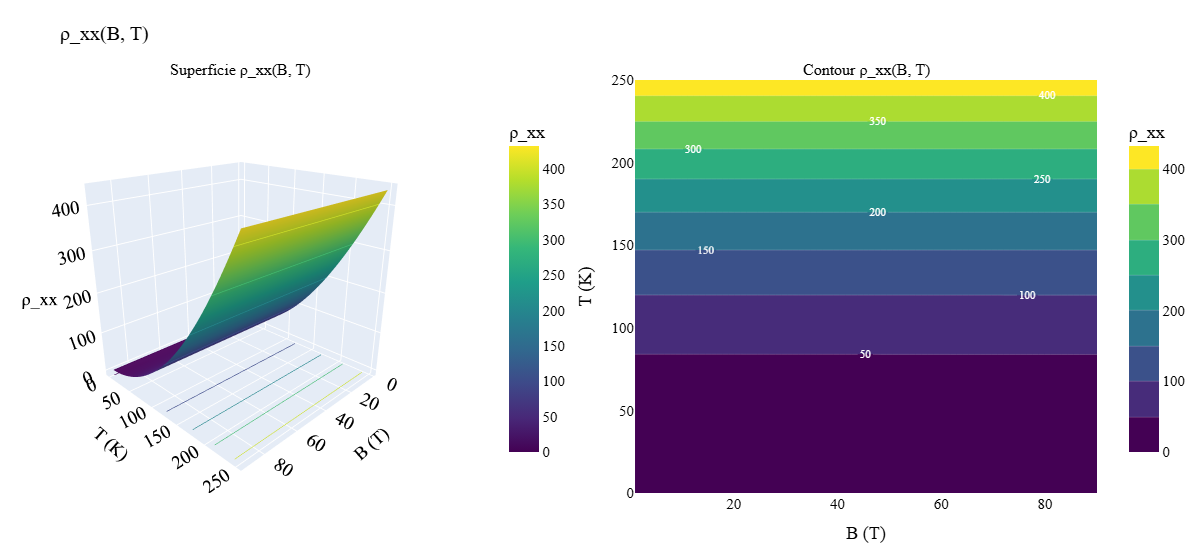

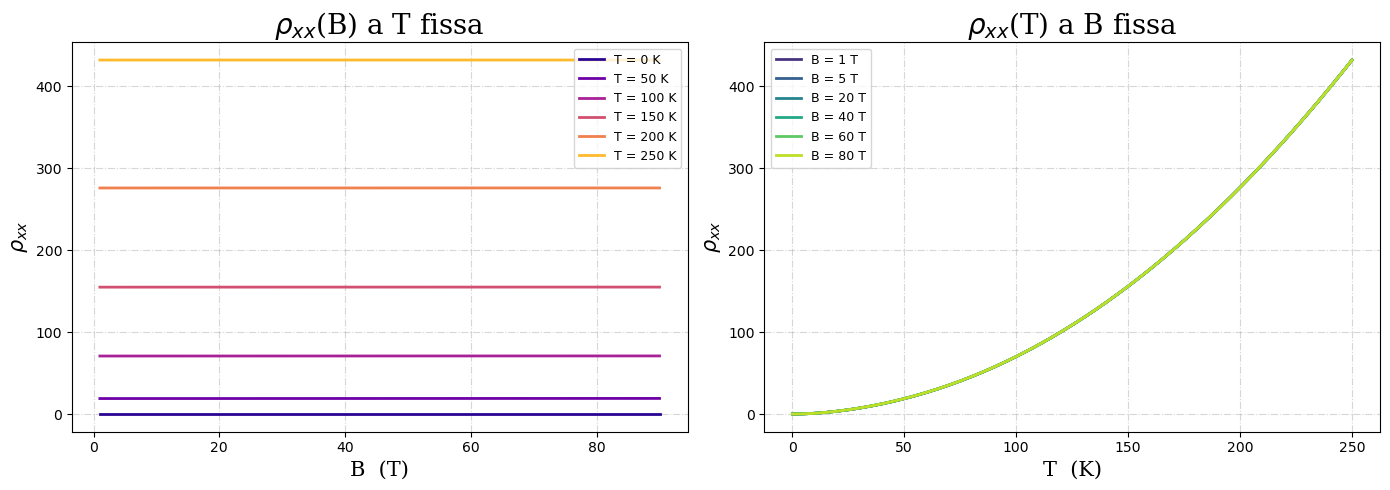

In [14]:
plot_observable_4panel(rho_xx_grid,
                       name='ρ_xx', name_tex=r'$\rho_{xx}$',
                       label_plain='ρ_xx', label_tex=r'$\rho_{xx}$',
                       B_grid_1d=B_grid_1d, T_grid_1d=T_grid_1d)


---
## Magnetoresistenza $\mathrm{MR}(B, T)$ — Gradino

$\mathrm{MR}(B, T) = \dfrac{\rho_{xx}(B, T)}{\rho_{xx}(0, T)} - 1$

Equivalente al rapporto $\rho(B)/\rho(0)$ usato da Ataei *et al.*, traslato di 1.

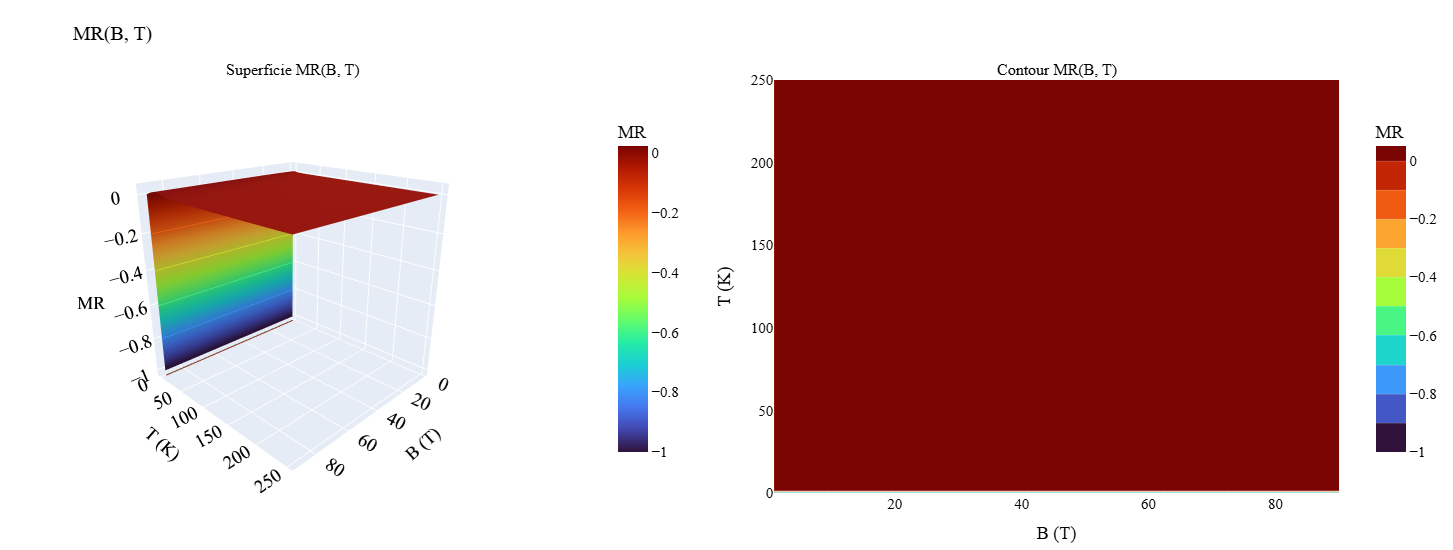

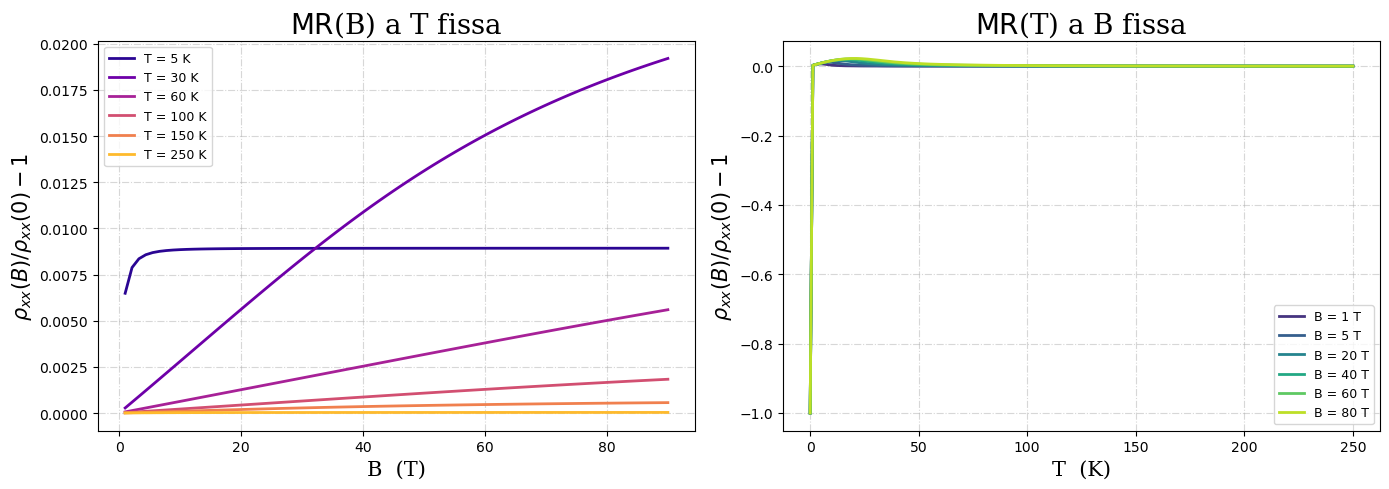

In [15]:
plot_observable_4panel(
    MR_grid,
    name='MR', name_tex=r'$\mathrm{MR}$',
    label_plain='MR', label_tex=r'$\rho_{xx}(B)/\rho_{xx}(0) - 1$',
    cmap='Turbo',
    B_grid_1d=B_grid_1d, T_grid_1d=T_grid_1d,
    T_slices=(5, 30, 60, 100, 150, 250),
)


---
## Coefficiente di Hall $R_H(B, T)$

$R_H = \dfrac{\rho_{xy}}{B} = -\dfrac{\sigma_{xy}}{B\,(\sigma_{xx}^2 + \sigma_{xy}^2)}$

Formula esatta (invertendo il tensore $\boldsymbol{\sigma}$). In regime di campo debole ($\sigma_{xy}\ll\sigma_{xx}$) si riduce a $R_H \approx -\sigma_{xy}/(B\sigma_{xx}^2)$.


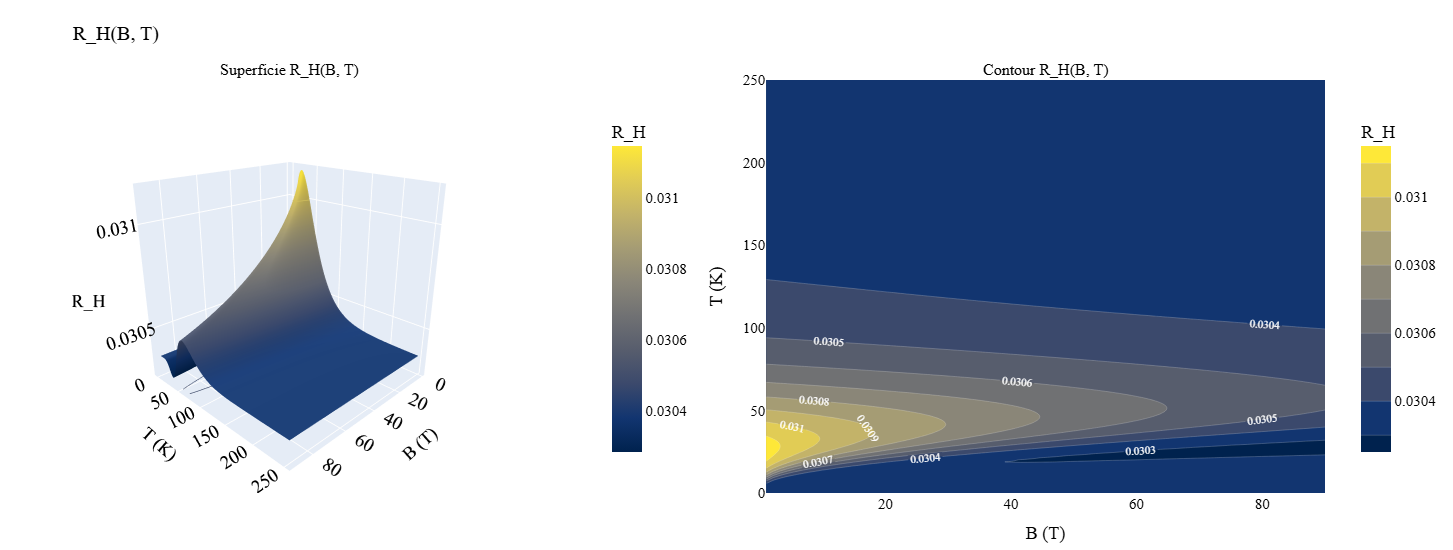

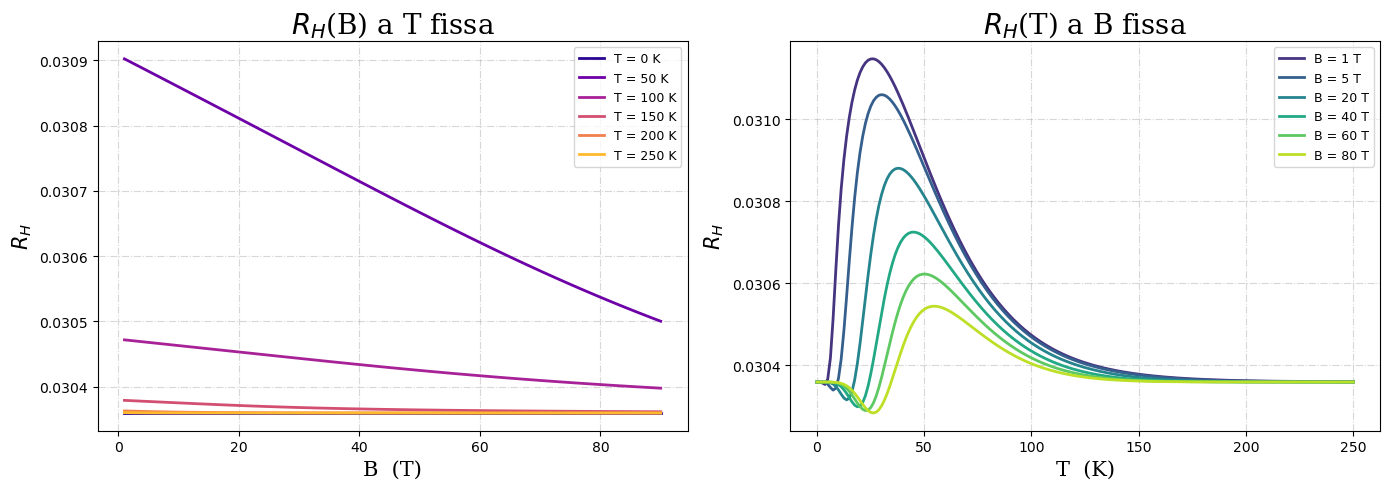

In [16]:
plot_observable_4panel(R_H_grid,
                       name='R_H', name_tex=r'$R_H$',
                       label_plain='R_H', label_tex=r'$R_H$',
                       cmap='Cividis',
                       B_grid_1d=B_grid_1d, T_grid_1d=T_grid_1d)


---
## Cotangente dell'angolo di Hall $\cot\theta_H(B, T)$

$\cot\theta_H = \dfrac{\sigma_{xx}}{\sigma_{xy}}$


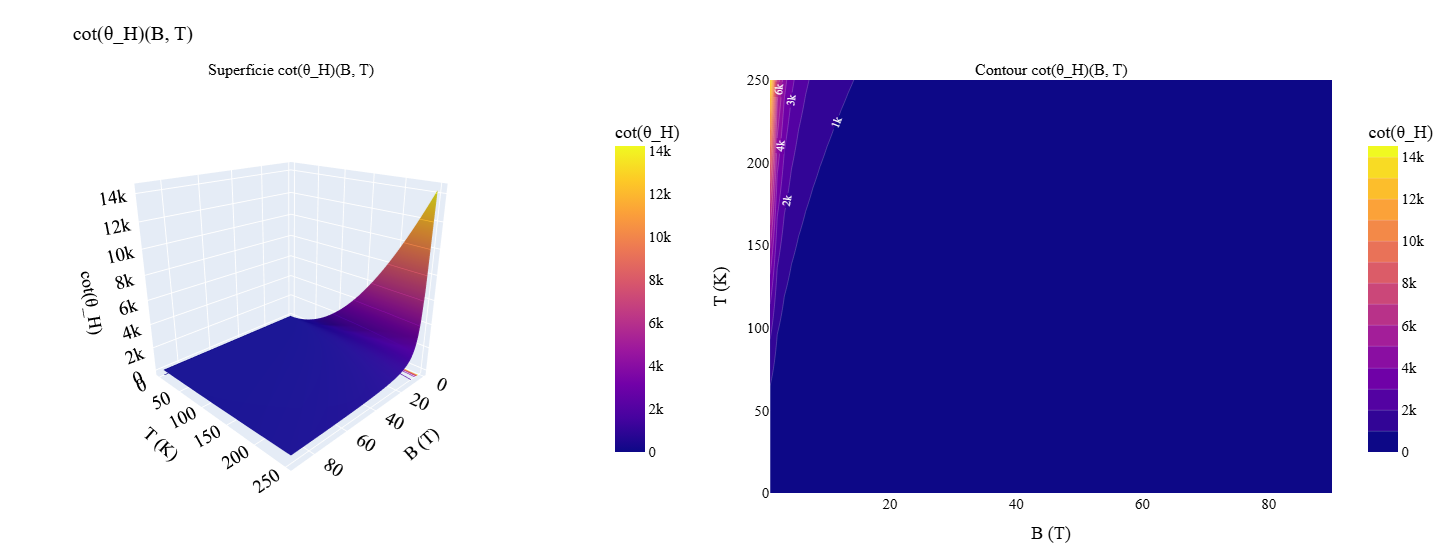

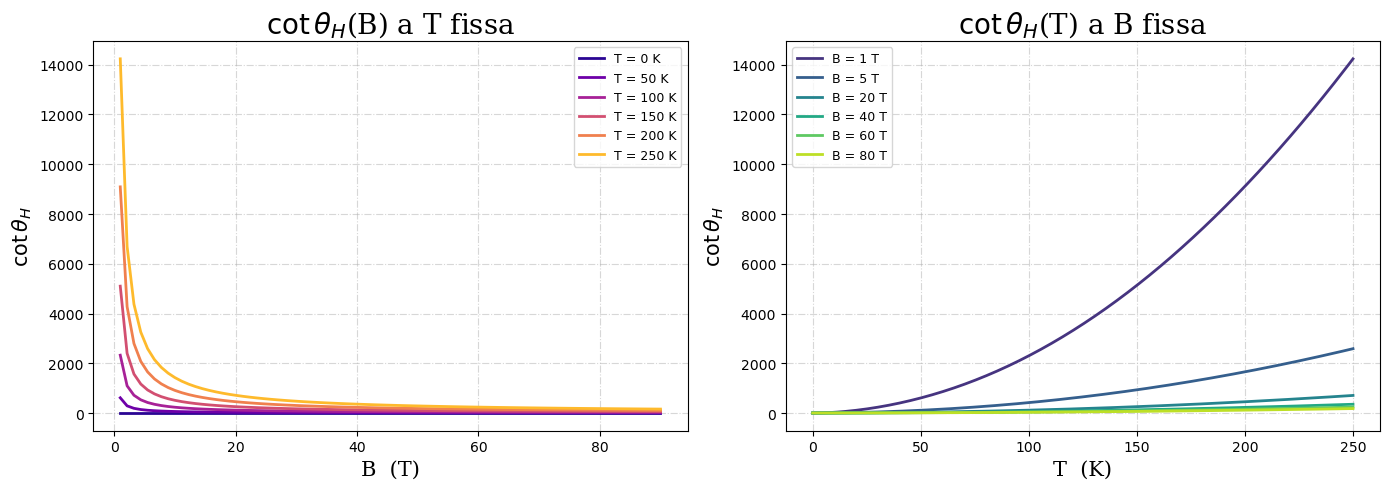

In [17]:
plot_observable_4panel(cot_H_grid,
                       name='cot(θ_H)', name_tex=r'$\cot\theta_H$',
                       label_plain='cot(θ_H)', label_tex=r'$\cot\theta_H$',
                       cmap='Plasma',
                       B_grid_1d=B_grid_1d, T_grid_1d=T_grid_1d)


### Vista adimensionale: $\rho_{xx}(T)$, $\cot\theta_H(T^2)$, $R_H(T)$ a $B$ fisso (modello a GRADINO)

- $\rho_{xx}$ atteso *lineare* in $T$.
- $\cot\theta_H$ atteso *lineare* in $T^2$.
- $R_H$ atteso con un picco a basso $T$.

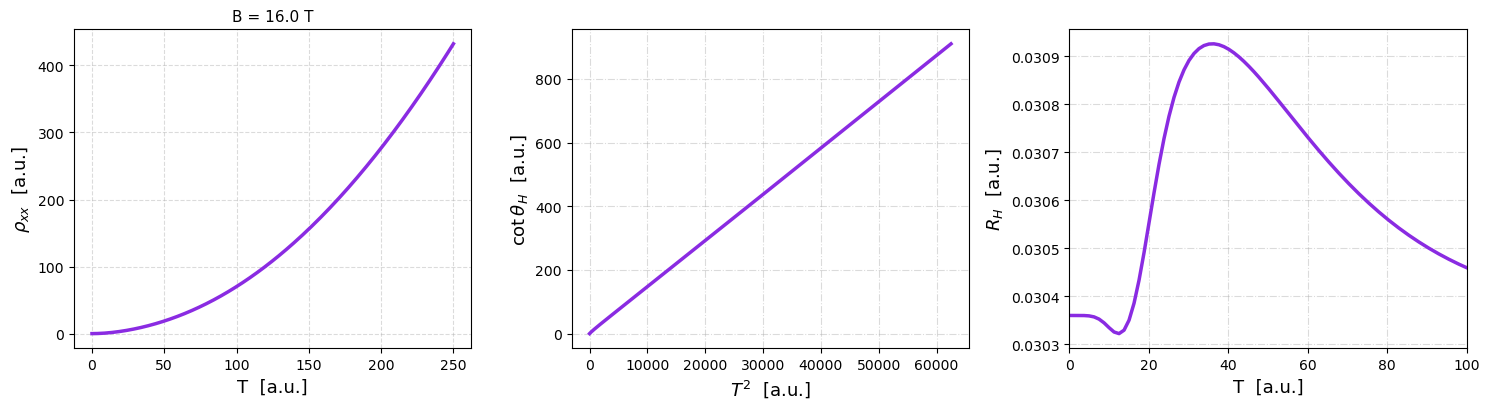

In [18]:
# Visualizzazione in a.u. a B fisso (modello a gradino)
B_ref = 16.0                                 # T
j_ref = int(np.argmin(np.abs(B_grid_1d - B_ref)))

rho_xx_au = rho_xx_grid[:, j_ref]
cot_H_au  = cot_H_grid[:, j_ref]  
R_H_au    = R_H_grid[:, j_ref]

fig, axs = plt.subplots(1, 3, figsize=(15, 4.2))
col = '#8A2BE2'

axs[0].plot(T_grid_1d, rho_xx_au, color=col, linewidth=2.5)
axs[0].set_xlabel('T  [a.u.]', fontsize=13)
axs[0].set_ylabel(r'$\rho_{xx}$  [a.u.]', fontsize=13)
axs[0].set_title(f'B = {B_ref} T', fontsize=11)
axs[0].grid(linestyle='--', alpha=0.45)

axs[1].plot(T_grid_1d**2, cot_H_au, color=col, linewidth=2.5)
axs[1].set_xlabel(r'$T^2$  [a.u.]', fontsize=13)
axs[1].set_ylabel(r'$\cot\theta_H$  [a.u.]', fontsize=13)
axs[1].grid(linestyle='-.', alpha=0.45)

axs[2].plot(T_grid_1d, R_H_au, color=col, linewidth=2.5)
axs[2].set_xlabel('T  [a.u.]', fontsize=13)
axs[2].set_ylabel(r'$R_H$  [a.u.]', fontsize=13)
axs[2].set_xlim(0, 100)
axs[2].grid(linestyle='-.', alpha=0.45)

plt.tight_layout()
plt.show()


---
## Dipendenza dalla temperatura (modello cos$^4$)

- $\Gamma_{is}(T) = a_{is}\,T$  **lineare in $T$** (scattering Planckian, $k_B T/\hbar$)
- $\Gamma_{an}(T) = \Gamma_{an}^{\rm fit}$  **costante** in $T$   (scattering anisotropo / *cold-spots*, Ong)

La scelta lineare per $G_{\rm is}$ è motivata dal fit $\rho(T) = \rho_0 + c\,T^p$ sui dati Ataei (MOESM1, notebook `Fit_Ataei.ipynb`) che dà $p \simeq 1$ su tutti e tre i campioni (LSCO S1/S2, Nd-LSCO). $G_{\rm an}$ costante conserva la struttura Ong-Chen-Anderson: $\Gamma_{an}/\Gamma_{is} \to \infty$ a $T\to 0$, quindi il picco di $R_H(T)$ a bassa $T$ viene ancora riprodotto.

In [19]:
# =================================================================
# Griglie (B, T) - modello BESSEL
# =================================================================

# Valori di riferimento dal fit (a T_exp, NON a T=0). Prefattore A=1 per convenzione.
G_is_fit, G_an_fit, m_star_B = popt_bessel
print(f'Fit Bessel (a T_exp={T_exp:.0f} K, A=1): '
      f'G_is={G_is_fit:.3f} meV, '
      f'G_an={G_an_fit:.3f} meV, m*={m_star_B:.3f} m_e')

# -- T-dipendenza Planckian (lineare in T per G_is) --------------------
#   G_is(T) = a_is * T     con a_is fissato da G_is(T_exp) = G_is_fit
#   G_an(T) = G_an_fit     costante (cold-spots, T-indipendente)
a_is = G_is_fit / T_exp
print(f'a_is      = {a_is:.5g} meV/K     (G_is(T) = a_is * T)')
print(f'G_an(T)   = {G_an_fit:.3f} meV costante   (cold-spots)')
# check: G_is(T_exp) deve coincidere con G_is_fit
print(f'check: G_is(T_exp) = {a_is*T_exp:.3f} meV  vs  G_is_fit = {G_is_fit:.3f} meV')

# Griglia (B, T) - riuso B_grid_1d, T_grid_1d gia' definiti
B_mesh_B, T_mesh_B = np.meshgrid(B_grid_1d, T_grid_1d)

sigxx_B_grid  = np.zeros_like(B_mesh_B)
sigxy_B_grid  = np.zeros_like(B_mesh_B)
sig0_xx_B_T   = np.zeros(T_grid_1d.shape)   # sigma_xx(B_ref, T) ~ sigma_0 [plateau]
sigxy_ref_T   = np.zeros(T_grid_1d.shape)   # sigma_xy(B_ref, T)
B_ref_T_arr   = np.zeros(T_grid_1d.shape)
for i, T in enumerate(T_grid_1d):
    G_is_v = G_is_T(T)
    G_an_v = G_an_T(T)
    B_ref  = _B_ref_bessel(G_an_v, m_star_B)
    B_ref_T_arr[i] = B_ref
    # Punto di riferimento nel plateau: alpha(B_ref) ~ 10, omega_c*tau << 1
    sig_ref         = _sigma_Bessel_complex(np.array([B_ref]), G_is_v, G_an_v, m_star_B)[0]
    sig0_xx_B_T[i]  = np.real(sig_ref)    # sigma_xx costante nel plateau
    sigxy_ref_T[i]  = np.imag(sig_ref)    # sigma_xy a B_ref (lineare in B sotto)
    # Per B >= B_ref: valuto direttamente la serie Bessel (numericamente stabile).
    # Per B <  B_ref: la somma iv(k, alpha) diverge; uso il limite Drude low-field:
    #   sigma_xx(B) = sigma_0           (plateau)
    #   sigma_xy(B) = sigma_xy(B_ref) * B/B_ref   (lineare in B, omega_c*tau << 1)
    mask = B_grid_1d >= B_ref
    if mask.any():
        sig = _sigma_Bessel_complex(B_grid_1d[mask], G_is_v, G_an_v, m_star_B)
        sigxx_B_grid[i, mask] = np.real(sig)
        sigxy_B_grid[i, mask] = np.imag(sig)
    sigxx_B_grid[i, ~mask] = sig0_xx_B_T[i]
    sigxy_B_grid[i, ~mask] = sigxy_ref_T[i] * (B_grid_1d[~mask] / B_ref)

# Quantita' derivate: formula tensoriale ESATTA per rho_xx
with np.errstate(divide='ignore', invalid='ignore'):
    rho_xx_B_grid = sigxx_B_grid / (sigxx_B_grid**2 + sigxy_B_grid**2)
    rho0_B_T      = 1.0 / sig0_xx_B_T
    MR_B_grid     = rho_xx_B_grid / rho0_B_T[:, None] - 1.0
    R_H_B_grid    = sigxy_B_grid / (B_mesh_B * (sigxx_B_grid**2 + sigxy_B_grid**2))
    cot_H_B_grid  = sigxx_B_grid / sigxy_B_grid

# Diagnostica: range di B_ref(T) - al di sopra tanto piu' stretto quanto T aumenta
print(f'B_ref(T) in [{B_ref_T_arr.min():.3g}, {B_ref_T_arr.max():.3g}] T   '
      f'(a B < B_ref uso il plateau per evitare overflow iv)')
print(f'rho_xx (Bessel)  in [{rho_xx_B_grid.min():.3g}, {rho_xx_B_grid.max():.3g}]')
print(f'MR     (Bessel)  in [{MR_B_grid.min():.3g}, {MR_B_grid.max():.3g}]')
print(f'R_H    (Bessel)  in [{R_H_B_grid.min():.3g}, {R_H_B_grid.max():.3g}]')
print(f'cot(θH)(Bessel)  in [{cot_H_B_grid.min():.3g}, {cot_H_B_grid.max():.3g}]')


Fit Bessel (a T_exp=30 K, A=1): G_is=17.700 meV, G_an=39.000 meV, m*=1.485 m_e
a_is      = 0.59 meV/K     (G_is(T) = a_is * T)
G_an(T)   = 39.000 meV costante   (cold-spots)
check: G_is(T_exp) = 17.700 meV  vs  G_is_fit = 17.700 meV
B_ref(T) in [6.24, 6.24] T   (a B < B_ref uso il plateau per evitare overflow iv)
rho_xx (Bessel)  in [1.05, 51.2]
MR     (Bessel)  in [-0.0319, 2.49]
R_H    (Bessel)  in [0.0222, 0.0388]
cot(θH)(Bessel)  in [1.89, 2.05e+03]


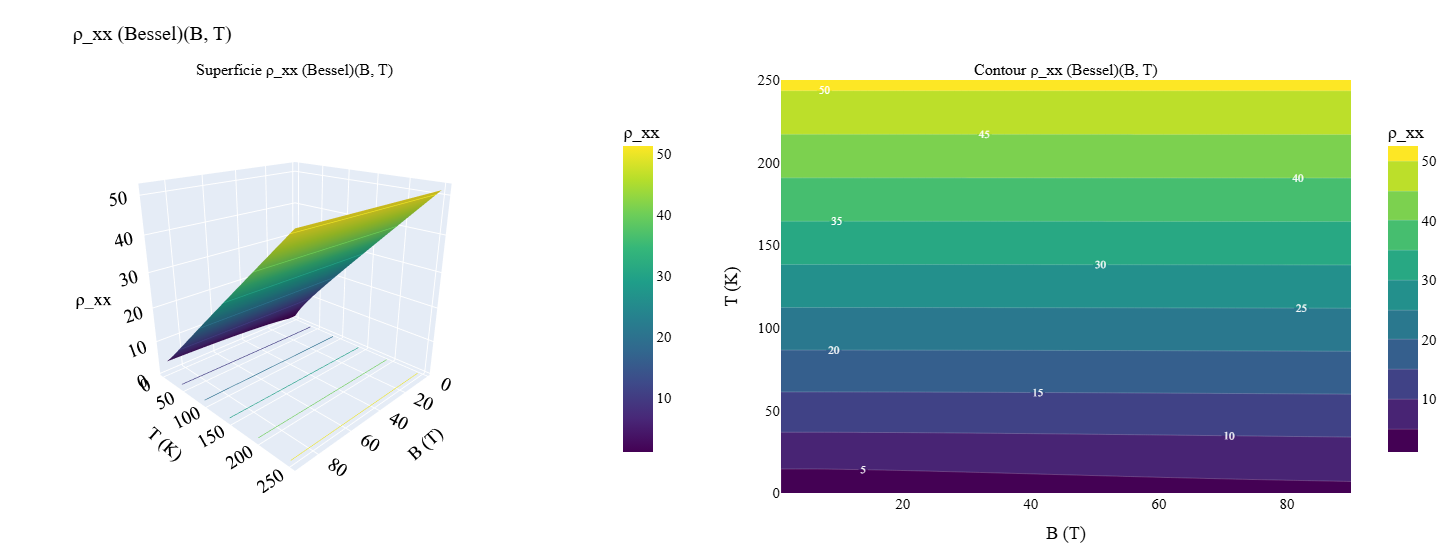

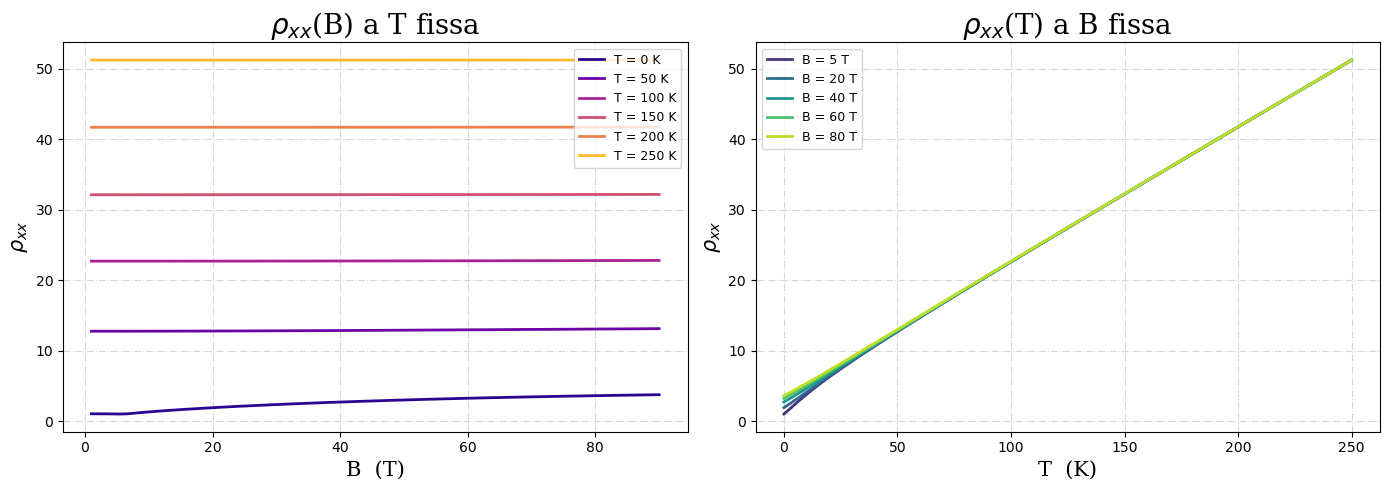

In [20]:
plot_observable_4panel(
    rho_xx_B_grid,
    name='ρ_xx (Bessel)', name_tex=r'$\rho_{xx}$',
    label_plain='ρ_xx',
    label_tex=r'$\rho_{xx}$',
    B_grid_1d=B_grid_1d, T_grid_1d=T_grid_1d,
    B_slices=(5, 20, 40, 60, 80),   # niente 1 T: somma Bessel non converge
)


---
## Magnetoresistenza $\mathrm{MR}(B, T)$ — Bessel

$\mathrm{MR}(B, T) = \dfrac{\rho_{xx}(B, T)}{\rho_{xx}(0, T)} - 1$

Nel modello Bessel $\rho_{xx}(0, T)$ e' stimato dal plateau della serie a $\alpha(B_{\mathrm{ref}}) \approx 10$. Per $B$ troppo basso la somma diverge numericamente (iv($k, \alpha$) overflow): in quella zona il plot mostra $\mathrm{MR} = 0$ (corrisponde al plateau fisico).

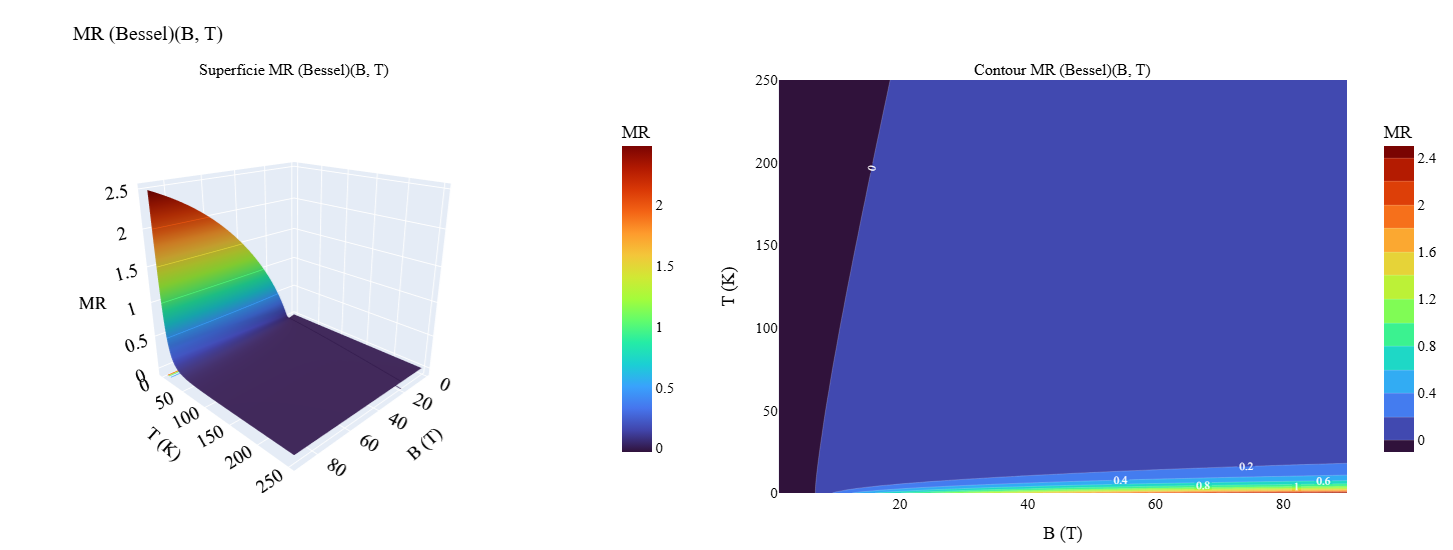

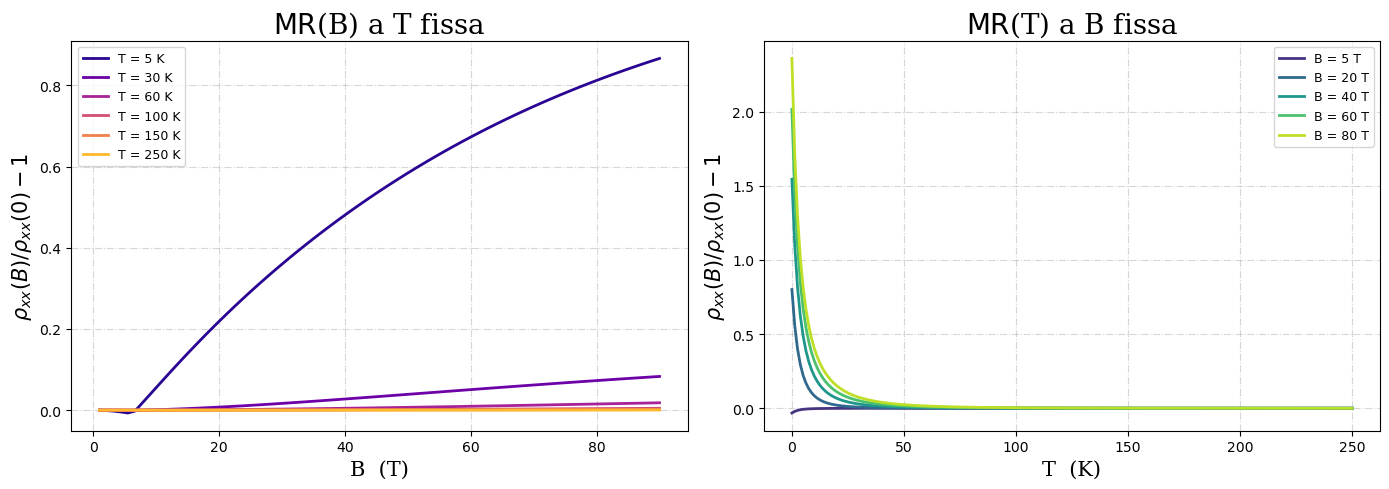

In [21]:
plot_observable_4panel(
    MR_B_grid,
    name='MR (Bessel)', name_tex=r'$\mathrm{MR}$',
    label_plain='MR', label_tex=r'$\rho_{xx}(B)/\rho_{xx}(0) - 1$',
    cmap='Turbo',
    B_grid_1d=B_grid_1d, T_grid_1d=T_grid_1d,
    T_slices=(5, 30, 60, 100, 150, 250),
    B_slices=(5, 20, 40, 60, 80),
)


---
### Coefficiente di Hall $R_H(B, T)$ — Bessel

$R_H = \dfrac{\rho_{xy}}{B} = -\dfrac{\sigma_{xy}}{B\,(\sigma_{xx}^2 + \sigma_{xy}^2)}$

Nel plateau ($B < B_{\mathrm{ref}}$, dove iv($k,\alpha$) diverge) uso il limite Drude low-field $\omega_c\tau \ll 1$: $\sigma_{xx} \simeq \sigma_0$ costante, $\sigma_{xy}(B) \simeq \sigma_{xy}(B_{\mathrm{ref}})\cdot B/B_{\mathrm{ref}}$ lineare in $B$. In questo regime $R_H \to \sigma_{xy,\mathrm{ref}}/(B_{\mathrm{ref}}\sigma_0^2)$ indipendente da $B$, come atteso.

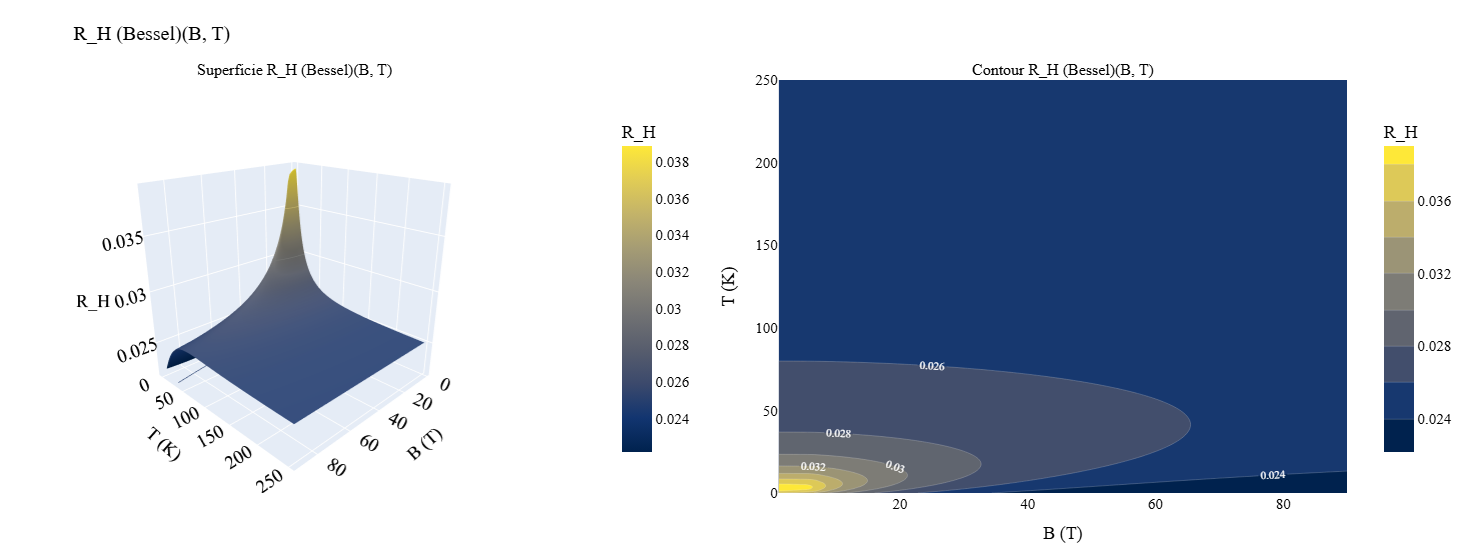

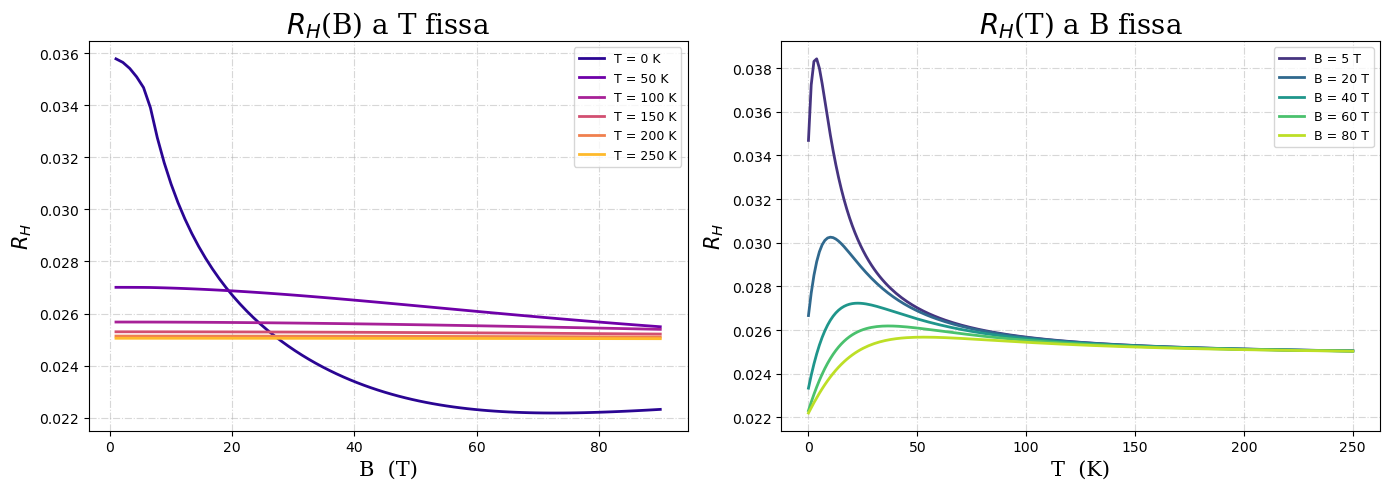

In [18]:
plot_observable_4panel(
    R_H_B_grid,
    name='R_H (Bessel)', name_tex=r'$R_H$',
    label_plain='R_H',
    label_tex=r'$R_H$',
    cmap='Cividis',
    B_grid_1d=B_grid_1d, T_grid_1d=T_grid_1d,
    B_slices=(5, 20, 40, 60, 80),
)


---
### Cotangente dell'angolo di Hall $\cot\theta_H(B, T)$ — Bessel

$\cot\theta_H = \dfrac{\sigma_{xx}}{\sigma_{xy}}$


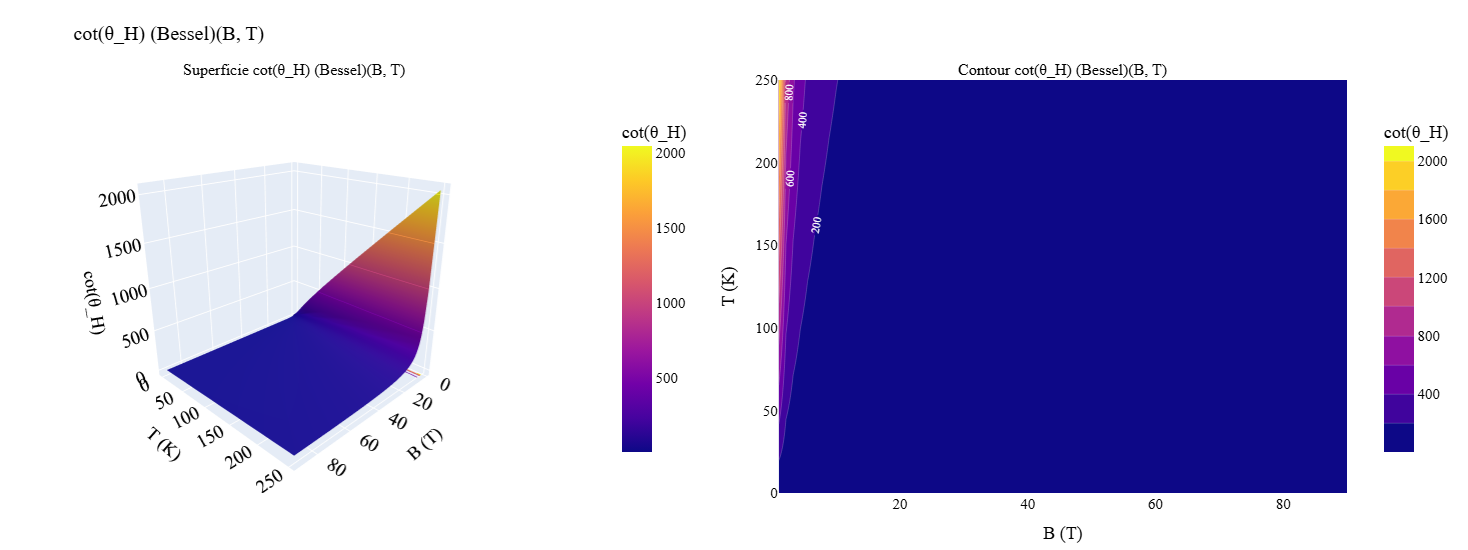

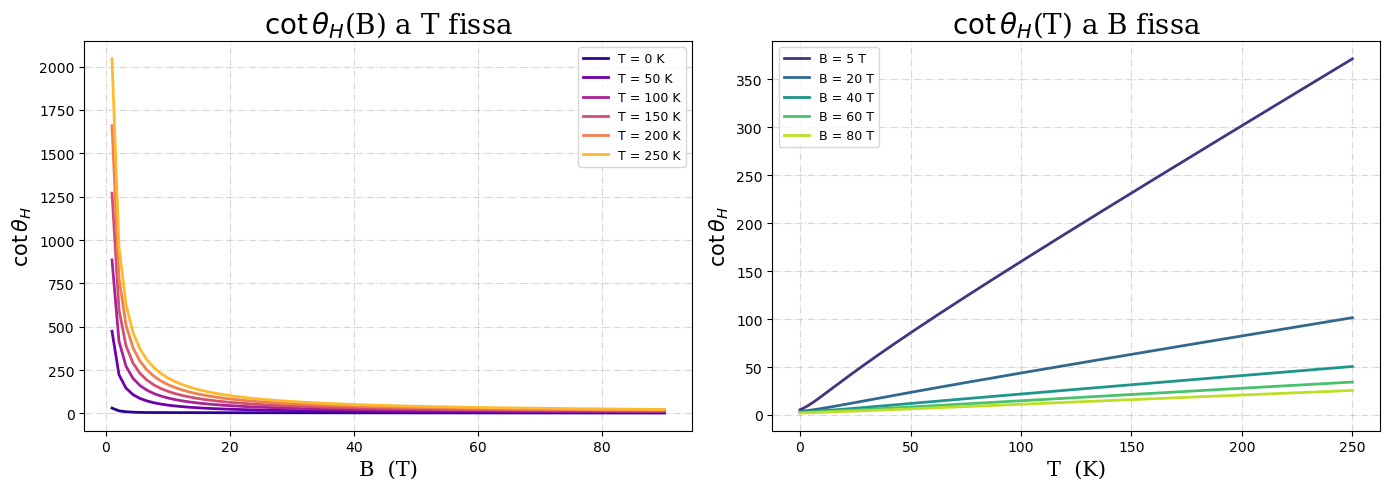

In [19]:
plot_observable_4panel(
    cot_H_B_grid,
    name='cot(θ_H) (Bessel)', name_tex=r'$\cot\theta_H$',
    label_plain='cot(θ_H)',
    label_tex=r'$\cot\theta_H$',
    cmap='Plasma',
    B_grid_1d=B_grid_1d, T_grid_1d=T_grid_1d,
    B_slices=(5, 20, 40, 60, 80),
)


### Vista adimensionale: $\rho_{xx}(T)$, $\cot\theta_H(T^2)$, $R_H(T)$ a $B$ fisso (modello BESSEL)

Stessa visualizzazione a.u. per il modello cos$^4$/Bessel. Per $B$ troppo bassi la somma in $t$ non converge: uso $B \geq 5$ T.


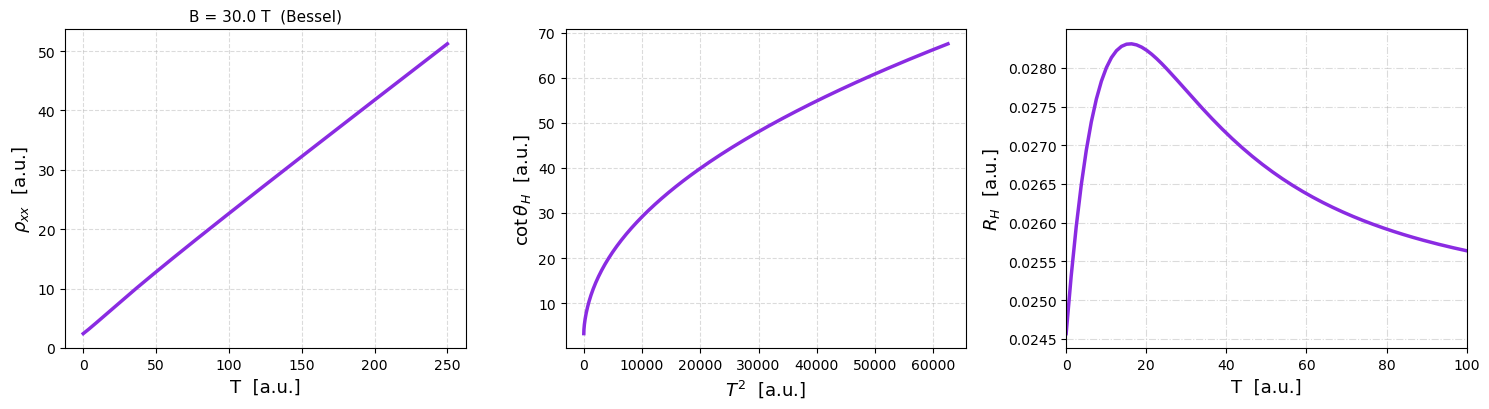

In [20]:
# Visualizzazione in a.u. a B fisso (modello Bessel)
B_ref_B = 30.0                                           
j_ref_B = int(np.argmin(np.abs(B_grid_1d - B_ref_B)))

rho_xx_B_au = rho_xx_B_grid[:, j_ref_B]
cot_H_B_au  = cot_H_B_grid[:, j_ref_B]
R_H_B_au    = R_H_B_grid[:, j_ref_B]

fig, axs = plt.subplots(1, 3, figsize=(15, 4.2))
col = '#8A2BE2'

axs[0].plot(T_grid_1d, rho_xx_B_au, color=col, linewidth=2.5)
axs[0].set_xlabel('T  [a.u.]', fontsize=13)
axs[0].set_ylabel(r'$\rho_{xx}$  [a.u.]', fontsize=13)
axs[0].set_title(f'B = {B_ref_B} T  (Bessel)', fontsize=11)
axs[0].grid(linestyle='--', alpha=0.45)

axs[1].plot(T_grid_1d**2, cot_H_B_au, color=col, linewidth=2.5)
axs[1].set_xlabel(r'$T^2$  [a.u.]', fontsize=13)
axs[1].set_ylabel(r'$\cot\theta_H$  [a.u.]', fontsize=13)
axs[1].grid(linestyle='--', alpha=0.45)

axs[2].plot(T_grid_1d, R_H_B_au, color=col, linewidth=2.5)
axs[2].set_xlabel('T  [a.u.]', fontsize=13)
axs[2].set_ylabel(r'$R_H$  [a.u.]', fontsize=13)
axs[2].set_xlim(0, 100)
axs[2].grid(linestyle='-.', alpha=0.45)

plt.tight_layout()
plt.show()
